# Predicción del precio del Bitcoin

Aquí vamos a crear un modelo de regresión usando únicamente los datos del archivo `datosBitcoin.csv`.

El objetivo es convertir fechas en formato `MM/DD/YYYY` a valores numéricos, entrenar un modelo con el historial de precios y comparar las predicciones del modelo con los valores reales disponibles en el archivo.

## 1. Importar librerías

Usamos `pandas` y `numpy` para trabajar con los datos, `matplotlib` para dibujar la gráfica, y `scikit-learn` para entrenar el modelo de regresión polinómica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

## 2. Cargar y preparar los datos

Leemos el archivo `datosBitcoin.csv`, convertimos la columna de fechas a un tipo datetime y limpiamos los precios para obtener valores numéricos que pueda usar el modelo.

In [2]:
datos = pd.read_csv('datosBitcoin.csv')
datos['Date'] = pd.to_datetime(datos['Date'], format='%m/%d/%Y')
datos['Price'] = datos['Price'].astype(str).str.replace(',', '', regex=False).astype(float)
datos = datos.sort_values('Date').reset_index(drop=True)
datos['dias_desde_inicio'] = (datos['Date'] - datos['Date'].min()).dt.days

print('Primeros registros:')
print(datos.head())
print(f'\nRegistros totales: {len(datos)}')
print(f"Rango de fechas: {datos['Date'].min().date()} a {datos['Date'].max().date()}")

Primeros registros:
        Date    Price  dias_desde_inicio
0 2025-04-22  93441.9                  0
1 2025-04-23  93697.7                  1
2 2025-04-24  93980.3                  2
3 2025-04-25  94676.9                  3
4 2025-04-26  94631.4                  4

Registros totales: 366
Rango de fechas: 2025-04-22 a 2026-04-22


## 3. Entrenar el modelo de regresión

Usamos como variable independiente el número de días transcurridos desde la primera fecha del archivo. Con esa variable ajustamos un modelo de regresión polinómica que capture cómo ha cambiado el precio del Bitcoin con el tiempo.

In [3]:
X = datos[['dias_desde_inicio']].values
y = datos['Price'].values

grado = 4
polinomio = PolynomialFeatures(degree=grado, include_bias=False)
X_polinomico = polinomio.fit_transform(X)

modelo = LinearRegression()
modelo.fit(X_polinomico, y)

y_pred_entrenamiento = modelo.predict(X_polinomico)
r2 = r2_score(y, y_pred_entrenamiento)

print(f'Grado del polinomio: {grado}')
print(f'Coeficientes: {modelo.coef_}')
print(f'Intercepto: {modelo.intercept_:.4f}')
print(f'R² del modelo: {r2:.4f}')

Grado del polinomio: 4
Coeficientes: [ 2.58527089e+02  4.07668347e-01 -1.22446004e-02  2.40040984e-05]
Intercepto: 95190.1973
R² del modelo: 0.9130


## 4. Funciones para predecir y consultar precios

Aquí definimos una función que toma una fecha en formato `MM/DD/YYYY` y devuelve el precio estimado por el modelo. También añadimos otra función para buscar el precio real dentro del archivo, si está disponible.

In [4]:
def convertir_fecha_a_dias(fecha_str):
    fecha = pd.to_datetime(fecha_str, format='%m/%d/%Y')
    return int((fecha - datos['Date'].min()).days)

def predecir_precio(fecha_str):
    dias = convertir_fecha_a_dias(fecha_str)
    X_nuevo = np.array([[dias]])
    X_nuevo_polinomico = polinomio.transform(X_nuevo)
    return float(modelo.predict(X_nuevo_polinomico)[0])

def obtener_precio_real(fecha_str):
    fecha = pd.to_datetime(fecha_str, format='%m/%d/%Y')
    coincidencia = datos.loc[datos['Date'] == fecha, 'Price']
    if coincidencia.empty:
        return np.nan
    return float(coincidencia.iloc[0])

## 5. Resultados solicitados

Para las fechas pedidas mostramos el precio real cuando está en el archivo, el precio predicho por el modelo y el porcentaje de desviación entre ambos.

Si el archivo no contiene la fecha, el precio real aparece como "N/D".

La fórmula usada es:

$$%dv = \frac{|valor\ real - valor\ predicho|}{valor\ real} \times 100$$

In [7]:
fechas_comparacion = ['04/23/2026', '04/24/2026', '04/25/2026']

resultados = []
for fecha_str in fechas_comparacion:
    precio_real = obtener_precio_real(fecha_str)
    precio_predicho = predecir_precio(fecha_str)
    if np.isnan(precio_real):
        desv = np.nan
        precio_real_text = 'N/D'
    else:
        desv = abs(precio_real - precio_predicho) / precio_real * 100
        precio_real_text = precio_real
    resultados.append({
        'Fecha': fecha_str,
        'Precio real': precio_real_text,
        'Precio predicho': precio_predicho,
        '%dv': desv
    })

tabla_resultados = pd.DataFrame(resultados)

print('Comparación entre precio real y predicción:')
print(tabla_resultados.to_string(index=False, float_format=lambda x: f'{x:,.2f}' if not pd.isna(x) else 'N/D'))

Comparación entre precio real y predicción:
     Fecha Precio real  Precio predicho  %dv
04/23/2026         N/D        74,828.32  NaN
04/24/2026         N/D        75,178.31  NaN
04/25/2026         N/D        75,540.95  NaN


## 6. Gráfica del ajuste

Mostramos el historial de precios del Bitcoin junto con la curva de predicción del modelo. La idea es ver cómo encaja el modelo en los datos reales y dónde quedan las fechas comparadas.

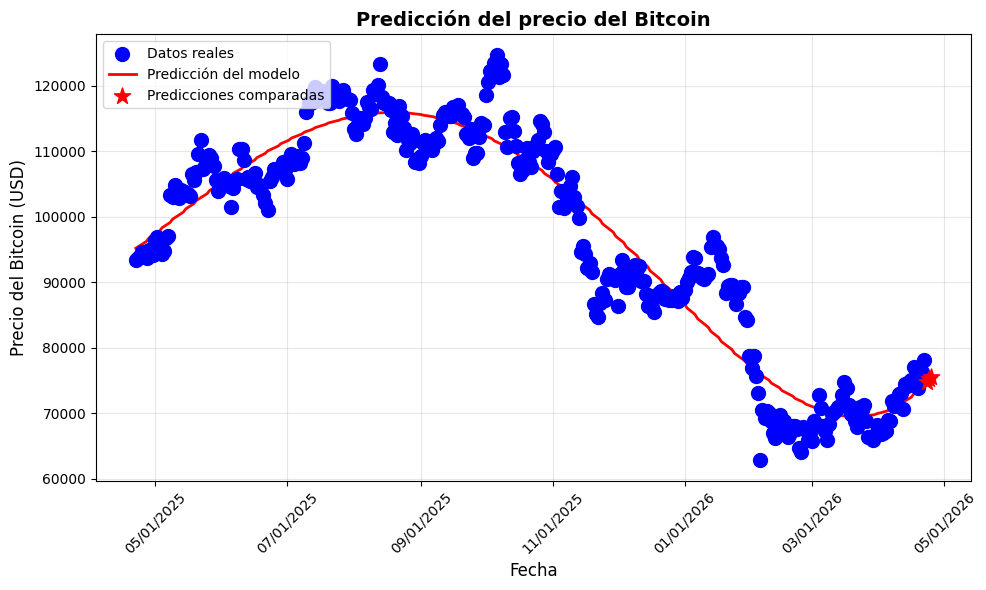

In [8]:
fechas_linea = pd.date_range(start=datos['Date'].min(), end=datos['Date'].max(), periods=300)
dias_linea = (fechas_linea - datos['Date'].min()).days.values.reshape(-1, 1)
y_linea = modelo.predict(polinomio.transform(dias_linea))

fechas_comparacion_dt = pd.to_datetime(fechas_comparacion, format='%m/%d/%Y')
precios_comparacion = np.array([predecir_precio(fecha) for fecha in fechas_comparacion])

plt.figure(figsize=(10, 6))

plt.scatter(datos['Date'], datos['Price'], color='blue', s=100, label='Datos reales', zorder=3)
plt.plot(fechas_linea, y_linea, color='red', linewidth=2, label='Predicción del modelo')
plt.scatter(fechas_comparacion_dt, precios_comparacion, color='red', s=150, marker='*', zorder=4, label='Predicciones comparadas')

plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio del Bitcoin (USD)', fontsize=12)
plt.title('Predicción del precio del Bitcoin', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d/%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Resumen

Este notebook usa solo `datosBitcoin.csv` para entrenar un modelo de regresión polinómica, convierte fechas en formato `MM/DD/YYYY` a valores numéricos, predice el precio del Bitcoin y compara esas predicciones con los valores reales cuando están disponibles. Además, muestra una gráfica que ilustra el ajuste del modelo sobre el historial de precios.